# WTA Benchmark Notebook

This notebook runs shortened benchmarks, generates plots, and performs additional simulations.

Note: some experiments reference the dataset published on Mendeley Data: https://data.mendeley.com/datasets/jt2ppwr62p/2 — the README also mentions this source.

Adjust `exact_time_limit_seconds` and the `sizes`/`seeds` lists before running full experiments to avoid long runtimes.

In [6]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import helper functions from the repository
# Load benchmark.py directly from the repository root to avoid import issues in notebooks
import importlib.util
repo_root = Path.cwd().parent  # Adjust if the notebook is in a subdirectory
benchmark_path = repo_root / 'benchmark.py'
import sys
# Ensure the package source dir is on sys.path so 'wta_optimization' can be imported
sys.path.insert(0, str(repo_root / 'src'))
spec = importlib.util.spec_from_file_location('benchmark', str(benchmark_path))
bm = importlib.util.module_from_spec(spec)
spec.loader.exec_module(bm)  # type: ignore
from wta_optimization.data import generate_random_instance, load_instance_from_file
from wta_optimization.heuristic import solve_greedy, solve_local_search, solve_simulated_annealing
from wta_optimization.exact import solve_exact
from wta_optimization.models import WTAInstance

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid')

## Quick file-based benchmark (shortened)
Run `run_benchmark(from_file=True)` with a reduced time limit — this provides a quick preview of results from input files.

In [7]:
# Warning: if you have many instances in data/WTA, consider running on 1-2 files first.
df_files = bm.run_benchmark(from_file=True, exact_time_limit_seconds=60, use_exact_warm_start=True)
display(df_files.head())
bm.plot_results(df_files, from_file=True)
bm.plot_tradeoff(df_files, from_file=True)

Starting WTA Optimization Benchmark (From Files)...
Exact MIP time limit per instance: 0.0 h
Exact MIP warm start from greedy: yes
File                 | Exact Time | Greedy T   | LS Time    | SA Time    | Gr Gap%  | LS Gap%  | SA Gap%  | Exact Status

Results saved to: results\benchmark_results_from_files.csv


""


KeyError: 'file'

<Figure size 1100x600 with 0 Axes>

## Short random benchmark
Run a small random set (short time limits) to quickly observe algorithm behavior.

In [8]:
df_rand = bm.run_benchmark(from_file=False, sizes=[5,10], seeds=[42], exact_time_limit_seconds=30, use_exact_warm_start=True)
display(df_rand)
bm.plot_results(df_rand, from_file=False)
bm.plot_tradeoff(df_rand, from_file=False)

Starting WTA Optimization Benchmark (Extended)...
Exact MIP time limit per instance: 0.0 h
Exact MIP warm start from greedy: yes
Size  | Seed | Exact Time | Greedy T   | LS Time    | SA Time    | Gr Gap%  | LS Gap%  | SA Gap%  | Exact Status
5     | 42   | 0.6650     | 0.0000     | 0.0003     | 0.0381     | 19.70    | 0.00     | 0.00     | Optimal     
10    | 42   | 0.3477     | 0.0000     | 0.0015     | 0.0362     | 36.34    | 7.93     | 9.75     | Optimal     

Results saved to: results\benchmark_results.csv


,size,seed,greedy_time_s,greedy_obj,greedy_status,optimality_gap_pct_greedy,ls_time_s,ls_obj,ls_status,optimality_gap_pct_ls,sa_time_s,sa_obj,sa_status,optimality_gap_pct_sa,exact_time_s,exact_obj,exact_status
0,5,42,0.000033,7.377131,heuristic,19.699394,0.000289,6.163048,heuristic,0.000000,0.038094,6.163048,heuristic,0.000000,0.664966,6.163048,Optimal
1,10,42,0.000029,11.124238,heuristic,36.338860,0.001533,8.806197,heuristic,7.928914,0.036198,8.954460,heuristic,9.746024,0.347727,8.159257,Optimal


Plots saved to results/
Trade-off summary saved to results\tradeoff_curve.csv


## Warm-start study (shortened)

In [9]:
warm_df = bm.run_warm_start_study(sizes=[5,10], seeds=[42], exact_time_limit_seconds=30)
display(warm_df)
bm.plot_warm_start_study(warm_df)


Starting Warm Start Study...
Size  | Seed | Cold MIP   | Warm MIP   | Speedup 
5     | 42   | 0.3813     | 0.3565     | 1.07    
10    | 42   | 0.6095     | 0.3562     | 1.71    
Warm start results saved to: results\warm_start_study.csv


,size,seed,greedy_obj,exact_cold_time_s,exact_warm_time_s,exact_cold_obj,exact_warm_obj,exact_cold_status,exact_warm_status,speedup_ratio,warm_start_gap_pct
0,5,42,7.377131,0.381297,0.356521,6.163048,6.163048,Optimal,Optimal,1.069494,19.699394
1,10,42,11.124238,0.609470,0.356215,8.159257,8.159257,Optimal,Optimal,1.710964,36.338860


## Sensitivity analysis (shortened)

In [10]:
sens_df = bm.run_sensitivity_analysis(exact_time_limit_seconds=30, use_exact_warm_start=True)
display(sens_df)
bm.plot_sensitivity_analysis(sens_df)

Sensitivity analysis saved to: results\sensitivity_analysis.csv


,scenario,method,runtime_s,objective_value,optimality_gap_pct,primary_focus_label,primary_focus_allocations,secondary_focus_label,secondary_focus_allocations,allocation_profile
0,High Value Target,Greedy,0.000045,30.151810,55.314452,Weapons on 100x target,3,,0,"3,1,1,1,0,0,1,1,1,1,1,1"
1,High Value Target,Greedy + Local Search,0.008824,21.238574,9.401639,Weapons on 100x target,3,,0,"3,1,0,1,0,1,1,1,1,1,1,1"
2,High Value Target,Simulated Annealing,0.047960,20.924451,7.783569,Weapons on 100x target,3,,0,"3,1,1,1,0,0,1,1,1,1,1,1"
3,High Value Target,Exact MIP,1.167130,19.413396,0.000000,Weapons on 100x target,2,,0,"2,1,1,1,0,1,1,1,1,1,1,1"
4,Reliability vs Quality,Greedy,0.000017,7.686000,17.630854,Weapons on highest-value target,5,Weapons on most reliable target,1,"5,1,2"
5,Reliability vs Quality,Greedy + Local Search,0.000135,6.534000,0.000000,Weapons on highest-value target,5,Weapons on most reliable target,1,"5,1,2"
6,Reliability vs Quality,Simulated Annealing,0.033444,6.534000,0.000000,Weapons on highest-value target,5,Weapons on most reliable target,1,"5,1,2"
7,Reliability vs Quality,Exact MIP,0.150634,6.534000,0.000000,Weapons on highest-value target,5,Weapons on most reliable target,1,"5,1,2"


## Additional simulation: scaling objective values
We will test how increasing the value of the highest-value target affects allocation choices and objective values across methods.

,multiplier,greedy_obj,ls_obj,sa_obj,exact_obj,greedy_alloc_primary,ls_alloc_primary,sa_alloc_primary,exact_alloc_primary
0,1,11.424652,9.320358,7.501190,7.501190,0,0,1,1
1,2,13.072220,8.067492,8.067492,8.067492,1,1,1,1
2,5,12.564425,11.439957,9.657307,9.653790,1,1,1,1
3,10,12.063559,10.821658,10.821658,10.821658,2,2,2,2
4,50,14.692788,13.450887,13.450887,13.450887,2,2,2,2
5,100,20.273477,16.072561,16.072561,16.072561,3,3,3,3


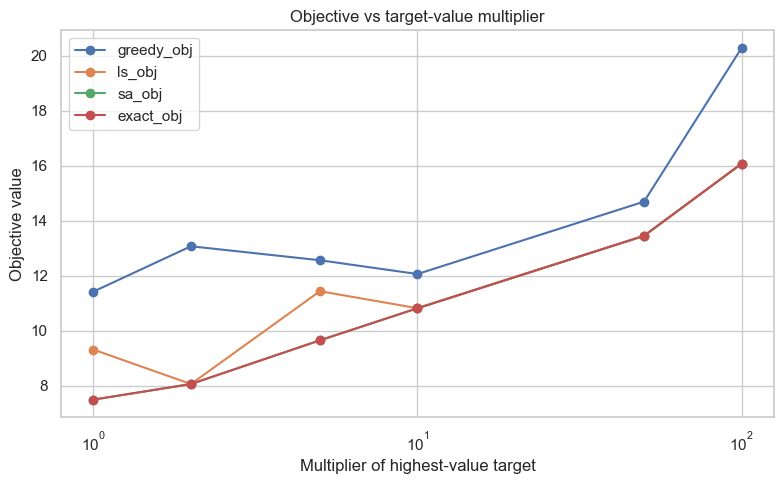

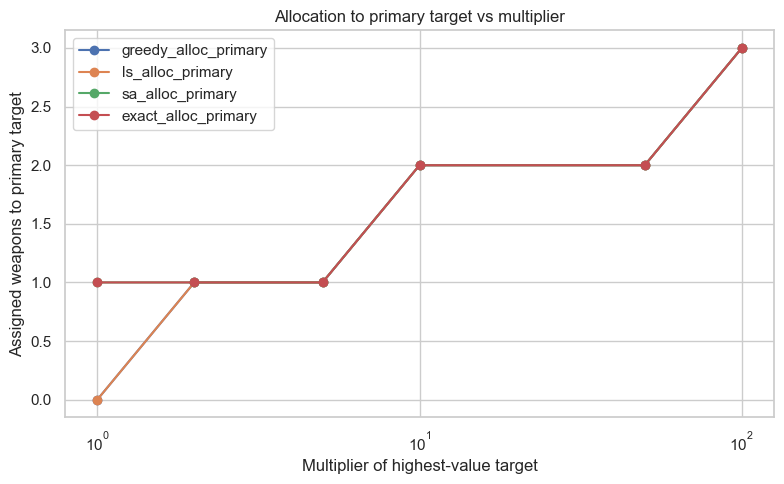

In [11]:
import math
multipliers = [1, 2, 5, 10, 50, 100]
records = []
base = generate_random_instance(weapons=8, targets=8, seed=2026)
for m in multipliers:
    tv = list(base.target_values)
    tv[0] = tv[0] * m
    inst = WTAInstance(weapons=base.weapons, targets=base.targets, target_values=tuple(tv), destruction_probabilities=base.destruction_probabilities)
    # greedy + ls + sa + exact (small time limit)
    g = solve_greedy(inst)
    ls = solve_local_search(inst)
    sa = solve_simulated_annealing(inst)
    try:
        ex = solve_exact(inst, num_piecewise_segments=20, warm_start=g, time_limit_seconds=20)
    except Exception as e:
        ex = None
    records.append({
        'multiplier': m,
        'greedy_obj': g.objective_value,
        'ls_obj': ls.objective_value,
        'sa_obj': sa.objective_value,
        'exact_obj': ex.objective_value if ex is not None else float('nan'),
        'greedy_alloc_primary': sum(row[0] for row in g.assignment),
        'ls_alloc_primary': sum(row[0] for row in ls.assignment),
        'sa_alloc_primary': sum(row[0] for row in sa.assignment),
        'exact_alloc_primary': sum(row[0] for row in ex.assignment) if ex is not None else float('nan'),
    })
sim_df = pd.DataFrame(records)
display(sim_df)
plt.figure(figsize=(8,5))
for col in ['greedy_obj','ls_obj','sa_obj','exact_obj']:
    plt.plot(sim_df['multiplier'], sim_df[col], marker='o', label=col)
plt.xscale('log')
plt.xlabel('Multiplier of highest-value target')
plt.ylabel('Objective value')
plt.title('Objective vs target-value multiplier')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sim_objective_vs_multiplier.png', dpi=200)
plt.show()

plt.figure(figsize=(8,5))
for col in ['greedy_alloc_primary','ls_alloc_primary','sa_alloc_primary','exact_alloc_primary']:
    plt.plot(sim_df['multiplier'], sim_df[col], marker='o', label=col)
plt.xscale('log')
plt.xlabel('Multiplier of highest-value target')
plt.ylabel('Assigned weapons to primary target')
plt.title('Allocation to primary target vs multiplier')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sim_alloc_vs_multiplier.png', dpi=200)
plt.show()

## Result files
Below is a list of generated files in the `results` directory.

In [ ]:
list(RESULTS_DIR.glob('*'))[:50]